# Исследование объявлений о продаже квартир

В вашем распоряжении данные сервиса Яндекс Недвижимость — архив объявлений о продаже квартир в Санкт-Петербурге и соседних населённых пунктах за несколько лет. Вам нужно научиться определять рыночную стоимость объектов недвижимости. Для этого проведите исследовательский анализ данных и установите параметры, влияющие на цену объектов. Это позволит построить автоматизированную систему: она отследит аномалии и мошенническую деятельность.

По каждой квартире на продажу доступны два вида данных. Первые вписаны пользователем, вторые — получены автоматически на основе картографических данных. Например, расстояние до центра, аэропорта и других объектов — эти данные автоматически получены из геосервисов. Количество парков и водоёмов также заполняется без участия пользователя.

## Откройте файл с данными и изучите общую информацию

### Импортируем библиотеку и просмотр данных

In [1]:
# импорт библиотеки
import pandas as pd
import seaborn as sns
import numpy as np
import warnings
import math

from matplotlib import pyplot as plt

In [2]:
# чтение файла data
try:
    #локальный файл
    data = pd.read_csv('/datasets/real_estate_data.csv', sep='\t')
except:
    # файл онлайн
    data = pd.read_csv('https://code.s3.yandex.net/datasets/real_estate_data.csv', sep='\t')

In [3]:
# выведим первых 20 значений data
data.head(20)

,total_images,last_price,total_area,first_day_exposition,rooms,ceiling_height,floors_total,living_area,floor,is_apartment,...,kitchen_area,balcony,locality_name,airports_nearest,cityCenters_nearest,parks_around3000,parks_nearest,ponds_around3000,ponds_nearest,days_exposition
0,20,13000000.0,108.00,2019-03-07T00:00:00,3,2.70,16.0,51.00,8,NaN,...,25.00,NaN,Санкт-Петербург,18863.0,16028.0,1.0,482.0,2.0,755.0,NaN
1,7,3350000.0,40.40,2018-12-04T00:00:00,1,NaN,11.0,18.60,1,NaN,...,11.00,2.0,посёлок Шушары,12817.0,18603.0,0.0,NaN,0.0,NaN,81.0
2,10,5196000.0,56.00,2015-08-20T00:00:00,2,NaN,5.0,34.30,4,NaN,...,8.30,0.0,Санкт-Петербург,21741.0,13933.0,1.0,90.0,2.0,574.0,558.0
3,0,64900000.0,159.00,2015-07-24T00:00:00,3,NaN,14.0,NaN,9,NaN,...,NaN,0.0,Санкт-Петербург,28098.0,6800.0,2.0,84.0,3.0,234.0,424.0
4,2,10000000.0,100.00,2018-06-19T00:00:00,2,3.03,14.0,32.00,13,NaN,...,41.00,NaN,Санкт-Петербург,31856.0,8098.0,2.0,112.0,1.0,48.0,121.0
5,10,2890000.0,30.40,2018-09-10T00:00:00,1,NaN,12.0,14.40,5,NaN,...,9.10,NaN,городской посёлок Янино-1,NaN,NaN,NaN,NaN,NaN,NaN,55.0
6,6,3700000.0,37.30,2017-11-02T00:00:00,1,NaN,26.0,10.60,6,NaN,...,14.40,1.0,посёлок Парголово,52996.0,19143.0,0.0,NaN,0.0,NaN,155.0
7,5,7915000.0,71.60,2019-04-18T00:00:00,2,NaN,24.0,NaN,22,NaN,...,18.90,2.0,Санкт-Петербург,23982.0,11634.0,0.0,NaN,0.0,NaN,NaN
8,20,2900000.0,33.16,2018-05-23T00:00:00,1,NaN,27.0,15.43,26,NaN,...,8.81,NaN,посёлок Мурино,NaN,NaN,NaN,NaN,NaN,NaN,189.0
9,18,5400000.0,61.00,2017-02-26T00:00:00,3,2.50,9.0,43.60,7,NaN,...,6.50,2.0,Санкт-Петербург,50898.0,15008.0,0.0,NaN,0.0,NaN,289.0


In [4]:
# выведим последних 5 значений data
data.tail(5)

,total_images,last_price,total_area,first_day_exposition,rooms,ceiling_height,floors_total,living_area,floor,is_apartment,...,kitchen_area,balcony,locality_name,airports_nearest,cityCenters_nearest,parks_around3000,parks_nearest,ponds_around3000,ponds_nearest,days_exposition
23694,9,9700000.0,133.81,2017-03-21T00:00:00,3,3.7,5.0,73.3,3,NaN,...,13.83,NaN,Санкт-Петербург,24665.0,4232.0,1.0,796.0,3.0,381.0,NaN
23695,14,3100000.0,59.00,2018-01-15T00:00:00,3,NaN,5.0,38.0,4,NaN,...,8.50,NaN,Тосно,NaN,NaN,NaN,NaN,NaN,NaN,45.0
23696,18,2500000.0,56.70,2018-02-11T00:00:00,2,NaN,3.0,29.7,1,NaN,...,NaN,NaN,село Рождествено,NaN,NaN,NaN,NaN,NaN,NaN,NaN
23697,13,11475000.0,76.75,2017-03-28T00:00:00,2,3.0,17.0,NaN,12,NaN,...,23.30,2.0,Санкт-Петербург,39140.0,10364.0,2.0,173.0,3.0,196.0,602.0
23698,4,1350000.0,32.30,2017-07-21T00:00:00,1,2.5,5.0,12.3,1,NaN,...,9.00,NaN,поселок Новый Учхоз,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [5]:
# просмотр основоной информации data
print(data.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23699 entries, 0 to 23698
Data columns (total 22 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   total_images          23699 non-null  int64  
 1   last_price            23699 non-null  float64
 2   total_area            23699 non-null  float64
 3   first_day_exposition  23699 non-null  object 
 4   rooms                 23699 non-null  int64  
 5   ceiling_height        14504 non-null  float64
 6   floors_total          23613 non-null  float64
 7   living_area           21796 non-null  float64
 8   floor                 23699 non-null  int64  
 9   is_apartment          2775 non-null   object 
 10  studio                23699 non-null  bool   
 11  open_plan             23699 non-null  bool   
 12  kitchen_area          21421 non-null  float64
 13  balcony               12180 non-null  float64
 14  locality_name         23650 non-null  object 
 15  airports_nearest   

### Построим гистограммы для всех числовых столбцов

In [6]:
# супер код обнуружения числовых столбцов
numeric_columns = data.select_dtypes(include='number').columns

In [7]:
# выведим название столбцов с числовыми данными
print(numeric_columns)

Index(['total_images', 'last_price', 'total_area', 'rooms', 'ceiling_height',
       'floors_total', 'living_area', 'floor', 'kitchen_area', 'balcony',
       'airports_nearest', 'cityCenters_nearest', 'parks_around3000',
       'parks_nearest', 'ponds_around3000', 'ponds_nearest',
       'days_exposition'],
      dtype='object')


array([[<AxesSubplot:title={'center':'total_images'}>,
        <AxesSubplot:title={'center':'last_price'}>,
        <AxesSubplot:title={'center':'total_area'}>,
        <AxesSubplot:title={'center':'rooms'}>],
       [<AxesSubplot:title={'center':'ceiling_height'}>,
        <AxesSubplot:title={'center':'floors_total'}>,
        <AxesSubplot:title={'center':'living_area'}>,
        <AxesSubplot:title={'center':'floor'}>],
       [<AxesSubplot:title={'center':'kitchen_area'}>,
        <AxesSubplot:title={'center':'balcony'}>,
        <AxesSubplot:title={'center':'airports_nearest'}>,
        <AxesSubplot:title={'center':'cityCenters_nearest'}>],
       [<AxesSubplot:title={'center':'parks_around3000'}>,
        <AxesSubplot:title={'center':'parks_nearest'}>,
        <AxesSubplot:title={'center':'ponds_around3000'}>,
        <AxesSubplot:title={'center':'ponds_nearest'}>],
       [<AxesSubplot:title={'center':'days_exposition'}>, <AxesSubplot:>,
        <AxesSubplot:>, <AxesSubplot:>]], d

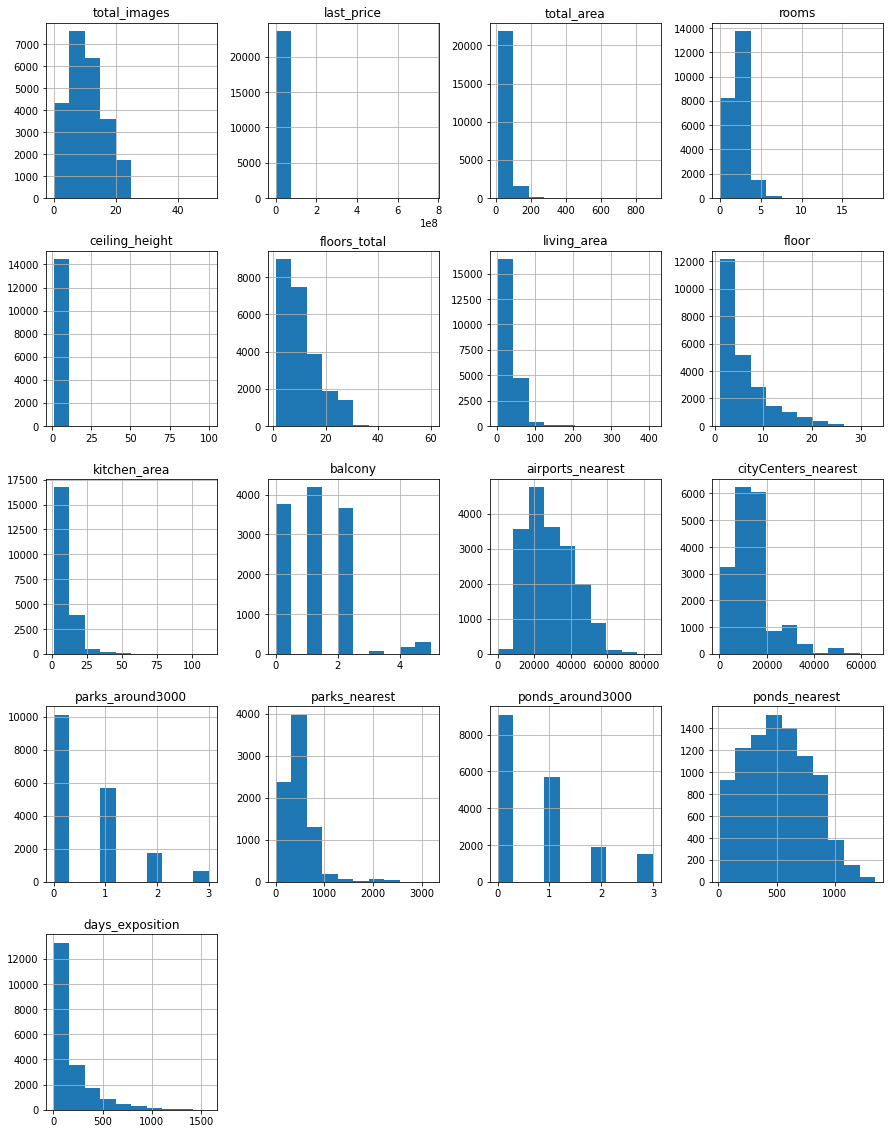

In [8]:
# построим супер гисторгаммы для списка numeric_cols
data[numeric_columns].hist(figsize=(15, 20))


 Изменила на plt.show(), а почему ошибка появилась?

### Вывод:
- В гистрограмма есть аномальные значения
- Есть пропущенные значения в данных



## Выполните предобработку данных

### Название колонок


In [9]:
# переименнуем явный отличающийся столбец, должно быть змеиный и с маленькой буквы.
data.rename(columns = {'cityCenters_nearest':'city_centers_nearest'}, inplace = True )

In [10]:
# выведим на экран
data['city_centers_nearest'].head(5)

0    16028.0
1    18603.0
2    13933.0
3     6800.0
4     8098.0
Name: city_centers_nearest, dtype: float64

In [11]:
# колонки под один формат сделаем
data.columns = data.columns.str.lower().str.replace(" ", "_")

In [12]:
# выведим на экран
data.head(5)

,total_images,last_price,total_area,first_day_exposition,rooms,ceiling_height,floors_total,living_area,floor,is_apartment,...,kitchen_area,balcony,locality_name,airports_nearest,city_centers_nearest,parks_around3000,parks_nearest,ponds_around3000,ponds_nearest,days_exposition
0,20,13000000.0,108.0,2019-03-07T00:00:00,3,2.70,16.0,51.0,8,NaN,...,25.0,NaN,Санкт-Петербург,18863.0,16028.0,1.0,482.0,2.0,755.0,NaN
1,7,3350000.0,40.4,2018-12-04T00:00:00,1,NaN,11.0,18.6,1,NaN,...,11.0,2.0,посёлок Шушары,12817.0,18603.0,0.0,NaN,0.0,NaN,81.0
2,10,5196000.0,56.0,2015-08-20T00:00:00,2,NaN,5.0,34.3,4,NaN,...,8.3,0.0,Санкт-Петербург,21741.0,13933.0,1.0,90.0,2.0,574.0,558.0
3,0,64900000.0,159.0,2015-07-24T00:00:00,3,NaN,14.0,NaN,9,NaN,...,NaN,0.0,Санкт-Петербург,28098.0,6800.0,2.0,84.0,3.0,234.0,424.0
4,2,10000000.0,100.0,2018-06-19T00:00:00,2,3.03,14.0,32.0,13,NaN,...,41.0,NaN,Санкт-Петербург,31856.0,8098.0,2.0,112.0,1.0,48.0,121.0


### Просмотр пропущеных значений

In [13]:
# выевдим пропущенны значения
data.isna().sum()

total_images                0
last_price                  0
total_area                  0
first_day_exposition        0
rooms                       0
ceiling_height           9195
floors_total               86
living_area              1903
floor                       0
is_apartment            20924
studio                      0
open_plan                   0
kitchen_area             2278
balcony                 11519
locality_name              49
airports_nearest         5542
city_centers_nearest     5519
parks_around3000         5518
parks_nearest           15620
ponds_around3000         5518
ponds_nearest           14589
days_exposition          3181
dtype: int64

In [14]:
# доли пропущеных значений
data.isna().mean()

total_images            0.000000
last_price              0.000000
total_area              0.000000
first_day_exposition    0.000000
rooms                   0.000000
ceiling_height          0.387991
floors_total            0.003629
living_area             0.080299
floor                   0.000000
is_apartment            0.882906
studio                  0.000000
open_plan               0.000000
kitchen_area            0.096122
balcony                 0.486054
locality_name           0.002068
airports_nearest        0.233850
city_centers_nearest    0.232879
parks_around3000        0.232837
parks_nearest           0.659100
ponds_around3000        0.232837
ponds_nearest           0.615596
days_exposition         0.134225
dtype: float64

Экспортирую библиотеку, ошибку выдает
- import missingno as msno
---------------------------------------------------------------------------
ModuleNotFoundError                       Traceback (most recent call last)
/tmp/ipykernel_111/1468494597.py in <module>
----> 1 import missingno as msno

ModuleNotFoundError: No module named 'missingno'


In [15]:
#import missingno as msno

In [16]:
# список пропущеных стобцов
columns_with_missing_data = data.isna().mean() > 0

print(columns_with_missing_data)

total_images            False
last_price              False
total_area              False
first_day_exposition    False
rooms                   False
ceiling_height           True
floors_total             True
living_area              True
floor                   False
is_apartment             True
studio                  False
open_plan               False
kitchen_area             True
balcony                  True
locality_name            True
airports_nearest         True
city_centers_nearest     True
parks_around3000         True
parks_nearest            True
ponds_around3000         True
ponds_nearest            True
days_exposition          True
dtype: bool


### Какие столбцы с пропущеными данные мы можем запонить?

#### Можем заменить значения

- balcony — число балконов - можем нулевым значением
- parks_around3000 — число парков в радиусе 3 км - можем нулевым значением
- ponds_around3000 — число водоёмов в радиусе 3 км - можем нулевым значением
- locality_name — название населённого пункта - можем на unknown
- is_apartment — апартаменты (булев тип) - поменяем на буллевое значение False

In [17]:
# заменим пустые значения на 0 по столбцам 'balcony','parks_around3000','ponds_around3000'
columns_fillna = ['balcony','parks_around3000','ponds_around3000']
data[columns_fillna] = data[columns_fillna].fillna(0)


In [18]:
# выведим первые 10 
data[columns_fillna].head(10)

,balcony,parks_around3000,ponds_around3000
0,0.0,1.0,2.0
1,2.0,0.0,0.0
2,0.0,1.0,2.0
3,0.0,2.0,3.0
4,0.0,2.0,1.0
5,0.0,0.0,0.0
6,1.0,0.0,0.0
7,2.0,0.0,0.0
8,0.0,0.0,0.0
9,2.0,0.0,0.0


In [19]:
# сделаем строчные буквы в столбце 'locality_name'
data['locality_name'] = data['locality_name'].str.lower()

In [20]:
# выведим все названия
data['locality_name'].unique()

array(['санкт-петербург', 'посёлок шушары', 'городской посёлок янино-1',
       'посёлок парголово', 'посёлок мурино', 'ломоносов', 'сертолово',
       'петергоф', 'пушкин', 'деревня кудрово', 'коммунар', 'колпино',
       'поселок городского типа красный бор', 'гатчина', 'поселок мурино',
       'деревня фёдоровское', 'выборг', 'кронштадт', 'кировск',
       'деревня новое девяткино', 'посёлок металлострой',
       'посёлок городского типа лебяжье',
       'посёлок городского типа сиверский', 'поселок молодцово',
       'поселок городского типа кузьмоловский',
       'садовое товарищество новая ропша', 'павловск',
       'деревня пикколово', 'всеволожск', 'волхов', 'кингисепп',
       'приозерск', 'сестрорецк', 'деревня куттузи', 'посёлок аннино',
       'поселок городского типа ефимовский', 'посёлок плодовое',
       'деревня заклинье', 'поселок торковичи', 'поселок первомайское',
       'красное село', 'посёлок понтонный', 'сясьстрой', 'деревня старая',
       'деревня лесколово', '

In [21]:
# заменим ё на е и заменим прифексы на пустое значение
data['locality_name'] = (
    data['locality_name']
    .str.replace('ё','е')
    .replace(['поселок ','при железнодорожной станции ', 'платформа ', 'садоводческое некоммерческое товарищество ',
             'садовое товарищество ', 'станции ', 'село ', 'пансионат ', 'городского типа ',
             'деревня ', 'городской поселок '], '', regex=True)
)

In [22]:
#выведим все названия после замены
data['locality_name'].unique()

array(['санкт-петербург', 'шушары', 'городской янино-1', 'парголово',
       'мурино', 'ломоносов', 'сертолово', 'петергоф', 'пушкин',
       'кудрово', 'коммунар', 'колпино', 'красный бор', 'гатчина',
       'федоровское', 'выборг', 'кронштадт', 'кировск', 'новое девяткино',
       'металлострой', 'лебяжье', 'сиверский', 'молодцово',
       'кузьмоловский', 'новая ропша', 'павловск', 'пикколово',
       'всеволожск', 'волхов', 'кингисепп', 'приозерск', 'сестрорецк',
       'куттузи', 'аннино', 'ефимовский', 'плодовое', 'заклинье',
       'торковичи', 'первомайское', 'красное село', 'понтонный',
       'сясьстрой', 'старая', 'лесколово', 'новый свет', 'сланцы',
       'путилово', 'ивангород', 'шлиссельбург', 'никольское',
       'зеленогорск', 'сосновый бор', 'оржицы', 'кальтино', 'романовка',
       'бугры', 'рощино', 'кириши', 'луга', 'волосово', 'отрадное',
       'павлово', 'оредеж', 'копорье', 'молодежное', 'тихвин', 'победа',
       'нурма', 'синявино', 'тосно', 'стрельна', 'бокс

In [23]:
# заменим названия где нет данных на unknown
data['locality_name'] = data['locality_name'].fillna('unknown')

In [24]:
data['locality_name'].unique()

array(['санкт-петербург', 'шушары', 'городской янино-1', 'парголово',
       'мурино', 'ломоносов', 'сертолово', 'петергоф', 'пушкин',
       'кудрово', 'коммунар', 'колпино', 'красный бор', 'гатчина',
       'федоровское', 'выборг', 'кронштадт', 'кировск', 'новое девяткино',
       'металлострой', 'лебяжье', 'сиверский', 'молодцово',
       'кузьмоловский', 'новая ропша', 'павловск', 'пикколово',
       'всеволожск', 'волхов', 'кингисепп', 'приозерск', 'сестрорецк',
       'куттузи', 'аннино', 'ефимовский', 'плодовое', 'заклинье',
       'торковичи', 'первомайское', 'красное село', 'понтонный',
       'сясьстрой', 'старая', 'лесколово', 'новый свет', 'сланцы',
       'путилово', 'ивангород', 'шлиссельбург', 'никольское',
       'зеленогорск', 'сосновый бор', 'оржицы', 'кальтино', 'романовка',
       'бугры', 'рощино', 'кириши', 'луга', 'волосово', 'отрадное',
       'павлово', 'оредеж', 'копорье', 'молодежное', 'тихвин', 'победа',
       'нурма', 'синявино', 'тосно', 'стрельна', 'бокс

In [25]:
data['locality_name'].value_counts()

санкт-петербург    15721
мурино               590
кудрово              472
шушары               440
всеволожск           398
                   ...  
хапо-ое                1
новолисино             1
лесная поляна          1
коммунары              1
красносельское         1
Name: locality_name, Length: 315, dtype: int64

In [26]:
# кол-во уникальных значений в названиях
data['locality_name'].nunique()

315

In [27]:
#посчитаем по всем столбцам уникальные значения
data.nunique()

total_images              38
last_price              2978
total_area              2182
first_day_exposition    1491
rooms                     17
ceiling_height           183
floors_total              36
living_area             1782
floor                     33
is_apartment               2
studio                     2
open_plan                  2
kitchen_area             971
balcony                    6
locality_name            315
airports_nearest        8275
city_centers_nearest    7642
parks_around3000           4
parks_nearest            995
ponds_around3000           4
ponds_nearest           1096
days_exposition         1141
dtype: int64

In [28]:
# is_apartment — апартаменты (булев тип) - поменяем на буллевое значение False
data['is_apartment'] = data['is_apartment'].fillna('False')

In [29]:
# выведим на экран
data.head(5)

,total_images,last_price,total_area,first_day_exposition,rooms,ceiling_height,floors_total,living_area,floor,is_apartment,...,kitchen_area,balcony,locality_name,airports_nearest,city_centers_nearest,parks_around3000,parks_nearest,ponds_around3000,ponds_nearest,days_exposition
0,20,13000000.0,108.0,2019-03-07T00:00:00,3,2.70,16.0,51.0,8,False,...,25.0,0.0,санкт-петербург,18863.0,16028.0,1.0,482.0,2.0,755.0,NaN
1,7,3350000.0,40.4,2018-12-04T00:00:00,1,NaN,11.0,18.6,1,False,...,11.0,2.0,шушары,12817.0,18603.0,0.0,NaN,0.0,NaN,81.0
2,10,5196000.0,56.0,2015-08-20T00:00:00,2,NaN,5.0,34.3,4,False,...,8.3,0.0,санкт-петербург,21741.0,13933.0,1.0,90.0,2.0,574.0,558.0
3,0,64900000.0,159.0,2015-07-24T00:00:00,3,NaN,14.0,NaN,9,False,...,NaN,0.0,санкт-петербург,28098.0,6800.0,2.0,84.0,3.0,234.0,424.0
4,2,10000000.0,100.0,2018-06-19T00:00:00,2,3.03,14.0,32.0,13,False,...,41.0,0.0,санкт-петербург,31856.0,8098.0,2.0,112.0,1.0,48.0,121.0


#### Не можем заменить значения

- ceiling_height — высота потолков (м)- не можем
- floors_total — всего этажей в доме - не можем
- living_area — жилая площадь в квадратных метрах (м²) - не може
- is_apartment — апартаменты (булев тип) - не можем
- kitchen_area — площадь кухни в квадратных метрах (м²) -не можем
- airports_nearest — расстояние до ближайшего аэропорта в метрах (м) - не можем
- cityCenters_nearest — расстояние до центра города (м) - не можем
- parks_nearest — расстояние до ближайшего парка (м) - не можем
- ponds_nearest — расстояние до ближайшего водоёма (м) - не можем
- days_exposition — сколько дней было размещено объявление (от публикации до снятия) - не можем

#### Вывод:
- Просмотрели явные пропущенные значения и заменили их
- Пропуски могли возникнуть из-за технических проблем, человеческий фактор заполнения, система не запрграмированна что бы не могли пропустить значения.


### Приведем формат даты в нормальный вид

In [30]:
# выведем 1 зпачение
data['first_day_exposition'][0]

'2019-03-07T00:00:00'

In [31]:
# тип данных
type(data['first_day_exposition'][0])

str

In [32]:
# изменим тип и формат даты first_day_exposition
data['first_day_exposition']= pd.to_datetime(data['first_day_exposition'], errors='coerce')
data['first_day_exposition'] = pd.to_datetime(data['first_day_exposition'], format='%m/%d/%Y %H:%M')

In [33]:
# выведим на экран
data['first_day_exposition'].head(5)

0   2019-03-07
1   2018-12-04
2   2015-08-20
3   2015-07-24
4   2018-06-19
Name: first_day_exposition, dtype: datetime64[ns]

In [34]:
# выведим первых 5 значений data
data.head(5)

,total_images,last_price,total_area,first_day_exposition,rooms,ceiling_height,floors_total,living_area,floor,is_apartment,...,kitchen_area,balcony,locality_name,airports_nearest,city_centers_nearest,parks_around3000,parks_nearest,ponds_around3000,ponds_nearest,days_exposition
0,20,13000000.0,108.0,2019-03-07,3,2.70,16.0,51.0,8,False,...,25.0,0.0,санкт-петербург,18863.0,16028.0,1.0,482.0,2.0,755.0,NaN
1,7,3350000.0,40.4,2018-12-04,1,NaN,11.0,18.6,1,False,...,11.0,2.0,шушары,12817.0,18603.0,0.0,NaN,0.0,NaN,81.0
2,10,5196000.0,56.0,2015-08-20,2,NaN,5.0,34.3,4,False,...,8.3,0.0,санкт-петербург,21741.0,13933.0,1.0,90.0,2.0,574.0,558.0
3,0,64900000.0,159.0,2015-07-24,3,NaN,14.0,NaN,9,False,...,NaN,0.0,санкт-петербург,28098.0,6800.0,2.0,84.0,3.0,234.0,424.0
4,2,10000000.0,100.0,2018-06-19,2,3.03,14.0,32.0,13,False,...,41.0,0.0,санкт-петербург,31856.0,8098.0,2.0,112.0,1.0,48.0,121.0


In [35]:
# выведим первую и последнию дату data
data['first_day_exposition'].min(), data['first_day_exposition'].max()

(Timestamp('2014-11-27 00:00:00'), Timestamp('2019-05-03 00:00:00'))

### Проверим тип данных

In [36]:
# выведим инфо
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23699 entries, 0 to 23698
Data columns (total 22 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   total_images          23699 non-null  int64         
 1   last_price            23699 non-null  float64       
 2   total_area            23699 non-null  float64       
 3   first_day_exposition  23699 non-null  datetime64[ns]
 4   rooms                 23699 non-null  int64         
 5   ceiling_height        14504 non-null  float64       
 6   floors_total          23613 non-null  float64       
 7   living_area           21796 non-null  float64       
 8   floor                 23699 non-null  int64         
 9   is_apartment          23699 non-null  object        
 10  studio                23699 non-null  bool          
 11  open_plan             23699 non-null  bool          
 12  kitchen_area          21421 non-null  float64       
 13  balcony         

По столбцам ниже нужно поменять тип данных:
-	airports_nearest — расстояние до ближайшего аэропорта в метрах (м)	-	число с плавающей точкой	float64
-	is_apartment — апартаменты (булев тип)	-	буллевый	bool
-	parks_around3000 — число парков в радиусе 3 км	-	целое число	int64
-	ponds_around3000 — число водоёмов в радиусе 3 км	-	целое число	int64




In [37]:
# заменим типы данных 'airports_nearest'
data['airports_nearest'].astype('float32')

0        18863.0
1        12817.0
2        21741.0
3        28098.0
4        31856.0
          ...   
23694    24665.0
23695        NaN
23696        NaN
23697    39140.0
23698        NaN
Name: airports_nearest, Length: 23699, dtype: float32

In [38]:
# заменим типы данных 'is_apartment'
data['is_apartment'].astype('bool')

0        True
1        True
2        True
3        True
4        True
         ... 
23694    True
23695    True
23696    True
23697    True
23698    True
Name: is_apartment, Length: 23699, dtype: bool

In [39]:
# заменим типы данных 'ponds_around3000
data['ponds_around3000'].astype('int32')

0        2
1        0
2        2
3        3
4        1
        ..
23694    3
23695    0
23696    0
23697    3
23698    0
Name: ponds_around3000, Length: 23699, dtype: int32

In [40]:
# заменим типы данных 'balcony'
data['balcony'].astype('int32')

0        0
1        2
2        0
3        0
4        0
        ..
23694    0
23695    0
23696    0
23697    2
23698    0
Name: balcony, Length: 23699, dtype: int32

In [41]:
# выведим инфо
print(data.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23699 entries, 0 to 23698
Data columns (total 22 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   total_images          23699 non-null  int64         
 1   last_price            23699 non-null  float64       
 2   total_area            23699 non-null  float64       
 3   first_day_exposition  23699 non-null  datetime64[ns]
 4   rooms                 23699 non-null  int64         
 5   ceiling_height        14504 non-null  float64       
 6   floors_total          23613 non-null  float64       
 7   living_area           21796 non-null  float64       
 8   floor                 23699 non-null  int64         
 9   is_apartment          23699 non-null  object        
 10  studio                23699 non-null  bool          
 11  open_plan             23699 non-null  bool          
 12  kitchen_area          21421 non-null  float64       
 13  balcony         

### Явные дубликаты

In [42]:
# число явных дубликатов
data.duplicated().sum()

0

Вывод: Явных дубликатов нет

### Вывод по выполнению предобработку данных

- заменили пустые значения
- исправили формат даты
- обработала явные и не явные дубликаты
- изменили тип данных там где нужно было

## Добавьте в таблицу новые столбцы

### Добавим столбцы с день недели, год-месяц, месяц, год

In [43]:
# создадим столбец с месяцем
data['first_day_exposition_weekday'] = data['first_day_exposition'].dt.weekday 

In [44]:
# выведим на экран
data['first_day_exposition_weekday'].unique()

array([3, 1, 4, 0, 2, 6, 5])

In [45]:
# создадим столбец с годом и месяцем, что бы можно было сводные смотреть
data['first_day_exposition_year_month'] = data['first_day_exposition'].dt.to_period("M")

In [46]:
data['first_day_exposition_year_month'].unique()

<PeriodArray>
['2019-03', '2018-12', '2015-08', '2015-07', '2018-06', '2018-09', '2017-11',
 '2019-04', '2018-05', '2017-02', '2018-08', '2016-06', '2017-07', '2016-09',
 '2017-01', '2019-01', '2017-09', '2018-03', '2017-04', '2016-10', '2015-10',
 '2017-05', '2017-12', '2016-04', '2018-02', '2017-10', '2016-05', '2018-10',
 '2017-06', '2018-11', '2017-03', '2016-03', '2018-01', '2017-08', '2015-12',
 '2018-07', '2019-02', '2014-12', '2018-04', '2016-12', '2015-09', '2015-02',
 '2015-11', '2016-11', '2015-01', '2016-02', '2016-08', '2015-06', '2015-03',
 '2016-01', '2019-05', '2015-05', '2015-04', '2016-07', '2014-11']
Length: 55, dtype: period[M]

In [47]:
# создадим столбец с месяцем
data['first_day_exposition_month'] = data['first_day_exposition'].dt.month 

In [48]:
# выведим на экран
data['first_day_exposition_month'].unique()

array([ 3, 12,  8,  7,  6,  9, 11,  4,  5,  2,  1, 10])

In [49]:
# создадим столбец с годом
data['first_day_exposition_year'] = data['first_day_exposition'].dt.year

In [50]:
# выведим на экран годы
data['first_day_exposition_year'].unique()

array([2019, 2018, 2015, 2017, 2016, 2014])

### Добавим столбцы категорийности

#### last_price  присвоим категории

In [51]:
# супер пупер код определения категорийности. Посмотрим столбец last_price  
pd.qcut(data['last_price'], 4)

0        (6800000.0, 763000000.0]
1          (12189.999, 3400000.0]
2          (4650000.0, 6800000.0]
3        (6800000.0, 763000000.0]
4        (6800000.0, 763000000.0]
                   ...           
23694    (6800000.0, 763000000.0]
23695      (12189.999, 3400000.0]
23696      (12189.999, 3400000.0]
23697    (6800000.0, 763000000.0]
23698      (12189.999, 3400000.0]
Name: last_price, Length: 23699, dtype: category
Categories (4, interval[float64]): [(12189.999, 3400000.0] < (3400000.0, 4650000.0] < (4650000.0, 6800000.0] < (6800000.0, 763000000.0]]

In [52]:
# так, по цене не поменяли тип
# Поменяем на целое чилсло 
data['last_price'].astype('int')

0        13000000
1         3350000
2         5196000
3        64900000
4        10000000
           ...   
23694     9700000
23695     3100000
23696     2500000
23697    11475000
23698     1350000
Name: last_price, Length: 23699, dtype: int64

In [53]:
# выведим на экран
data['last_price'].unique()

array([13000000.,  3350000.,  5196000., ...,  6151120., 21400000.,
       11475000.])

In [54]:
# Посмотрим минимальное и максимальное значение
data['last_price'].min(), data['last_price'].max()

(12190.0, 763000000.0)

Очень большой разброс.

In [55]:
# Посмотрим категорийность на 5 шагов
pd.qcut(data['last_price'], 5)

0        (7585000.0, 763000000.0]
1          (3190000.0, 4104250.4]
2          (4104250.4, 5295000.0]
3        (7585000.0, 763000000.0]
4        (7585000.0, 763000000.0]
                   ...           
23694    (7585000.0, 763000000.0]
23695      (12189.999, 3190000.0]
23696      (12189.999, 3190000.0]
23697    (7585000.0, 763000000.0]
23698      (12189.999, 3190000.0]
Name: last_price, Length: 23699, dtype: category
Categories (5, interval[float64]): [(12189.999, 3190000.0] < (3190000.0, 4104250.4] < (4104250.4, 5295000.0] < (5295000.0, 7585000.0] < (7585000.0, 763000000.0]]

In [56]:
# Добавим столбец с категорями цен
data['last_price_category'] = pd.qcut(data['last_price'], 5, labels=['A_price', 'B_price', 'C_price', 'D_price', 'E_price'])

In [57]:
# выведим на экран
data['last_price_category'].head()

0    E_price
1    B_price
2    C_price
3    E_price
4    E_price
Name: last_price_category, dtype: category
Categories (5, object): ['A_price' < 'B_price' < 'C_price' < 'D_price' < 'E_price']

#### добавим столбец цена за 1 кв метр и присвоим категории

In [58]:
# Создадим столбец с расчетом цены за 1 квадратный метр price_per_square_meter
# это last_price деленная на total_area
data['price_per_square_meter'] = data['last_price'] / data['total_area']

In [59]:
#выведим на экран
data['price_per_square_meter'].head()

0    120370.370370
1     82920.792079
2     92785.714286
3    408176.100629
4    100000.000000
Name: price_per_square_meter, dtype: float64

In [60]:
# изменим тип на int
data['price_per_square_meter'].astype('int')

0        120370
1         82920
2         92785
3        408176
4        100000
          ...  
23694     72490
23695     52542
23696     44091
23697    149511
23698     41795
Name: price_per_square_meter, Length: 23699, dtype: int64

In [61]:
# выведим на экран
data['price_per_square_meter'].head()

0    120370.370370
1     82920.792079
2     92785.714286
3    408176.100629
4    100000.000000
Name: price_per_square_meter, dtype: float64

Так, что то не работает

In [62]:
# округлим столбец до 0 значений после точки
data['price_per_square_meter'].round(0)

0        120370.0
1         82921.0
2         92786.0
3        408176.0
4        100000.0
           ...   
23694     72491.0
23695     52542.0
23696     44092.0
23697    149511.0
23698     41796.0
Name: price_per_square_meter, Length: 23699, dtype: float64

In [63]:
# выведим на экран
data['price_per_square_meter'].head()

0    120370.370370
1     82920.792079
2     92785.714286
3    408176.100629
4    100000.000000
Name: price_per_square_meter, dtype: float64

Поняла нужно перезаписать знчание

In [64]:
data['price_per_square_meter'] = data['price_per_square_meter'].round(0)

In [65]:
# выведим на экран
data['price_per_square_meter'].head()

0    120370.0
1     82921.0
2     92786.0
3    408176.0
4    100000.0
Name: price_per_square_meter, dtype: float64

In [66]:
# Посмотрим категорийность на 5 шагов
pd.qcut(data['price_per_square_meter'], 5)

0        (120232.0, 1907500.0]
1           (71212.0, 88235.0]
2          (88235.0, 101471.0]
3        (120232.0, 1907500.0]
4          (88235.0, 101471.0]
                 ...          
23694       (71212.0, 88235.0]
23695       (111.999, 71212.0]
23696       (111.999, 71212.0]
23697    (120232.0, 1907500.0]
23698       (111.999, 71212.0]
Name: price_per_square_meter, Length: 23699, dtype: category
Categories (5, interval[float64]): [(111.999, 71212.0] < (71212.0, 88235.0] < (88235.0, 101471.0] < (101471.0, 120232.0] < (120232.0, 1907500.0]]

In [67]:
# Создадим столбец и присвоим категории
data['price_per_square_meter_category'] = pd.qcut(data['price_per_square_meter'], 5, labels=['A_price_square_meter', 'B_price_square_meter', 'C_price_square_meter', 'D_price_square_meter', 'E_price_square_meter'])

In [68]:
# Выведим на экран
display(data.head(10))

,total_images,last_price,total_area,first_day_exposition,rooms,ceiling_height,floors_total,living_area,floor,is_apartment,...,ponds_around3000,ponds_nearest,days_exposition,first_day_exposition_weekday,first_day_exposition_year_month,first_day_exposition_month,first_day_exposition_year,last_price_category,price_per_square_meter,price_per_square_meter_category
0,20,13000000.0,108.00,2019-03-07,3,2.70,16.0,51.00,8,False,...,2.0,755.0,NaN,3,2019-03,3,2019,E_price,120370.0,E_price_square_meter
1,7,3350000.0,40.40,2018-12-04,1,NaN,11.0,18.60,1,False,...,0.0,NaN,81.0,1,2018-12,12,2018,B_price,82921.0,B_price_square_meter
2,10,5196000.0,56.00,2015-08-20,2,NaN,5.0,34.30,4,False,...,2.0,574.0,558.0,3,2015-08,8,2015,C_price,92786.0,C_price_square_meter
3,0,64900000.0,159.00,2015-07-24,3,NaN,14.0,NaN,9,False,...,3.0,234.0,424.0,4,2015-07,7,2015,E_price,408176.0,E_price_square_meter
4,2,10000000.0,100.00,2018-06-19,2,3.03,14.0,32.00,13,False,...,1.0,48.0,121.0,1,2018-06,6,2018,E_price,100000.0,C_price_square_meter
5,10,2890000.0,30.40,2018-09-10,1,NaN,12.0,14.40,5,False,...,0.0,NaN,55.0,0,2018-09,9,2018,A_price,95066.0,C_price_square_meter
6,6,3700000.0,37.30,2017-11-02,1,NaN,26.0,10.60,6,False,...,0.0,NaN,155.0,3,2017-11,11,2017,B_price,99196.0,C_price_square_meter
7,5,7915000.0,71.60,2019-04-18,2,NaN,24.0,NaN,22,False,...,0.0,NaN,NaN,3,2019-04,4,2019,E_price,110545.0,D_price_square_meter
8,20,2900000.0,33.16,2018-05-23,1,NaN,27.0,15.43,26,False,...,0.0,NaN,189.0,2,2018-05,5,2018,A_price,87455.0,B_price_square_meter
9,18,5400000.0,61.00,2017-02-26,3,2.50,9.0,43.60,7,False,...,0.0,NaN,289.0,6,2017-02,2,2017,D_price,88525.0,C_price_square_meter


###  Добавить столбец тип этажа квартиры (значения — «первый», «последний», «другой»)

In [69]:
# создадим фугкция для определения певрвого, последнего и другого этажа
def floor(row):
    """Эта супер функция определит тип этажа
    если этаж = 1 - первый
    если этаж равен этажности дома - последний
    если не равно 1 и второму пукту то другое. """
    if row['floor'] == 1:
        return 'первый'
    if row['floor'] == row['floors_total']:
        return 'последний'
    return 'другое'

In [70]:
# добавим столбец floor_type где будут категории
data['floor_type'] = data.apply(floor, axis=1)

In [71]:
# выедим на экран
data['floor_type'].head()

0    другое
1    первый
2    другое
3    другое
4    другое
Name: floor_type, dtype: object

### Добавиv столбец расстояние до центра города в километрах

In [72]:
# посчитаем сколько км до центра города
data['dist_to_the_city_center'] = (data['city_centers_nearest'] / 1000).round()

In [73]:
# выведим на экран 
data['dist_to_the_city_center'].unique()

array([16., 19., 14.,  7.,  8., nan, 12., 15., 52., 33., 31., 11., 13.,
       10.,  2., 32.,  4., 17., 30.,  5., 51., 50., 24., 18.,  9., 28.,
        3.,  6., 27., 21., 49., 35., 36., 34.,  1., 29., 26., 53., 22.,
       55., 20., 23., 25.,  0., 66., 47., 40., 57., 37., 41., 43., 48.,
       62., 60., 39., 42., 65., 54., 59., 45., 61., 63.])

In [74]:
# выведим первую и последнию 'dist_to_the_city_center'
data['dist_to_the_city_center'].min(), data['dist_to_the_city_center'].max()

(0.0, 66.0)

In [75]:
# Посмотрим категорийность на 5 шагов
pd.qcut(data['dist_to_the_city_center'], 5)

0         (14.0, 17.0]
1         (17.0, 66.0]
2         (12.0, 14.0]
3        (-0.001, 8.0]
4        (-0.001, 8.0]
             ...      
23694    (-0.001, 8.0]
23695              NaN
23696              NaN
23697      (8.0, 12.0]
23698              NaN
Name: dist_to_the_city_center, Length: 23699, dtype: category
Categories (5, interval[float64]): [(-0.001, 8.0] < (8.0, 12.0] < (12.0, 14.0] < (14.0, 17.0] < (17.0, 66.0]]

In [76]:
# Создадим столбец и присвоим категории
data['dist_city_center_category'] = pd.qcut(data['dist_to_the_city_center'], 5, labels=['A_city_center', 'B_city_center', 'C_city_center', 'D_city_center', 'E_city_center'])

In [77]:
# выведим на экран
data['dist_city_center_category'].head()

0    D_city_center
1    E_city_center
2    C_city_center
3    A_city_center
4    A_city_center
Name: dist_city_center_category, dtype: category
Categories (5, object): ['A_city_center' < 'B_city_center' < 'C_city_center' < 'D_city_center' < 'E_city_center']

### Вывод:
- добавили столбцы категорийности
- добавили столбцы день недели, месяц, год и месяц_год
- добавили столбец цены за квадратный метр стоимости недвижимости
- добавили столбец растояние до центра города


## Проведите исследовательский анализ данных

### Изучим параметр общая площадь

In [78]:
# выведим сводную статистику по total_area
data['total_area'].describe()

count    23699.000000
mean        60.348651
std         35.654083
min         12.000000
25%         40.000000
50%         52.000000
75%         69.900000
max        900.000000
Name: total_area, dtype: float64

Text(0.5, 1.0, 'общая площадь от от 0 до 900')

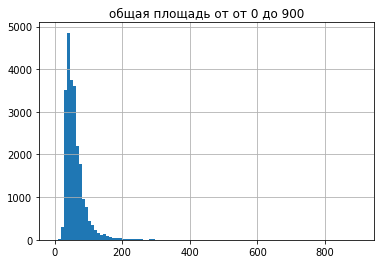

In [79]:
# выведим гистограмму от 0 до 900
data['total_area'].hist(range =(0,900),bins=100)
plt.title('общая площадь от от 0 до 900')


Видим что скопление от 12 до 200 основное

Text(0.5, 1.0, 'общая площадь от 12 до 200')

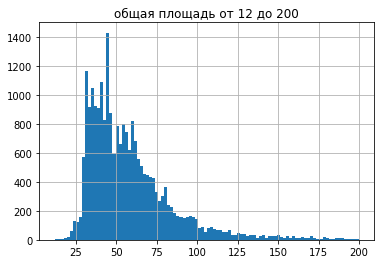

In [80]:
# выведим гистограмму от 12 до 200
data['total_area'].hist(range =(12,200),bins=100)
plt.title('общая площадь от 12 до 200')

Видим скопление от 25 до 75

Text(0.5, 1.0, 'общая площадь от 25 до 75')

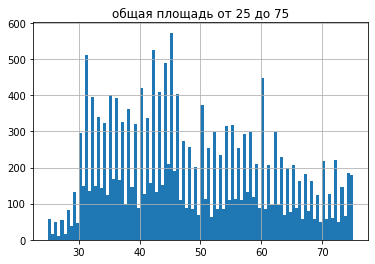

In [81]:
# выведим гистограмму от 25 до 75
data['total_area'].hist(range =(25,75),bins=100)
plt.title('общая площадь от 25 до 75')

Наблюдаем основной показатель с 30 до 60 кв. м

In [82]:
# создадим категорийность 
pd.qcut(data['total_area'], 10)

0        (93.52, 900.0]
1          (37.6, 42.0]
2          (52.0, 58.0]
3        (93.52, 900.0]
4        (93.52, 900.0]
              ...      
23694    (93.52, 900.0]
23695      (58.0, 64.8]
23696      (52.0, 58.0]
23697     (75.0, 93.52]
23698    (11.999, 33.0]
Name: total_area, Length: 23699, dtype: category
Categories (10, interval[float64]): [(11.999, 33.0] < (33.0, 37.6] < (37.6, 42.0] < (42.0, 46.0] ... (58.0, 64.8] < (64.8, 75.0] < (75.0, 93.52] < (93.52, 900.0]]

In [83]:
# Создадим столбец и присвоим категории 'total_area_category'
data['total_area_category'] = pd.qcut(data['total_area'], 10, labels=['1', '2', '3','4', '5', '6','7', '8', '9','10'])

In [84]:
# создадим групировку 'total_area_category'

total_area_category_group = data.groupby('total_area_category')['last_price'].count()

In [85]:
display(total_area_category_group)

total_area_category
1     2552
2     2206
3     2394
4     2577
5     2226
6     2348
7     2289
8     2494
9     2243
10    2370
Name: last_price, dtype: int64

 При просмотрк с категориями, то кол-во квартир примерно везде одинакове. Максимум в 4 группе это от 42.0 до 46.0

### Изучим параметр жилая площадь

In [86]:
# выведим сводную статистику по living_area
data['living_area'].describe()

count    21796.000000
mean        34.457852
std         22.030445
min          2.000000
25%         18.600000
50%         30.000000
75%         42.300000
max        409.700000
Name: living_area, dtype: float64

<AxesSubplot:>

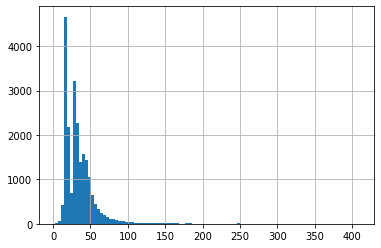

In [87]:
# выведим гистограмму от 2 до 409
data['living_area'].hist(range =(2,409),bins=100)

<AxesSubplot:>

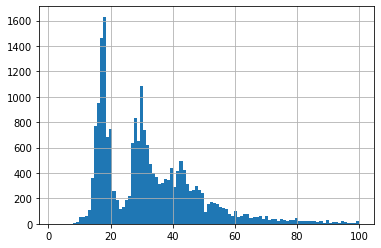

In [88]:
# выведим гистограмму от 2 до 100
data['living_area'].hist(range =(2,100),bins=100)

<AxesSubplot:>

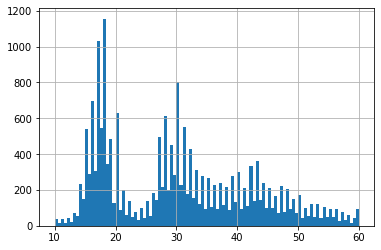

In [89]:
# выведим гистограмму от 10 до 60
data['living_area'].hist(range =(10,60),bins=100)

Text(0.5, 1.0, 'общая площадь от 10 до 20')

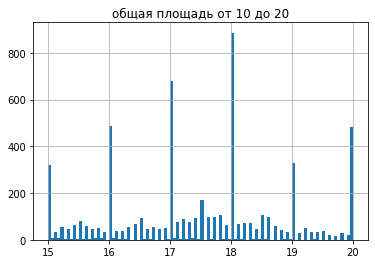

In [90]:
# выведим гистограмму от 10 до 20
data['living_area'].hist(range =(15,20),bins=100)
plt.title('общая площадь от 10 до 20')


Text(0.5, 1.0, 'общая площадь от 25 до 35')

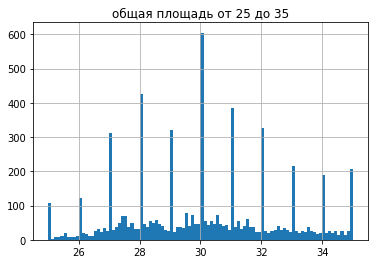

In [91]:
# выведим гистограмму от 25 до 35
data['living_area'].hist(range =(25,35),bins=100)
plt.title('общая площадь от 25 до 35')


что то не вышло, разделила графики

Видим показатель от 15 до 20 и от 27 до 35

### Изучим параметр площадь кухни

In [92]:
# выведим сводную статистику по kitchen_area
data['kitchen_area'].describe()

count    21421.000000
mean        10.569807
std          5.905438
min          1.300000
25%          7.000000
50%          9.100000
75%         12.000000
max        112.000000
Name: kitchen_area, dtype: float64

<AxesSubplot:>

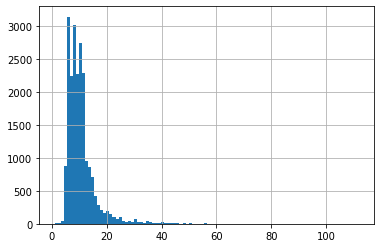

In [93]:
# выведим гистограмму от 1 до 112
data['kitchen_area'].hist(range =(1,112),bins=100)

<AxesSubplot:>

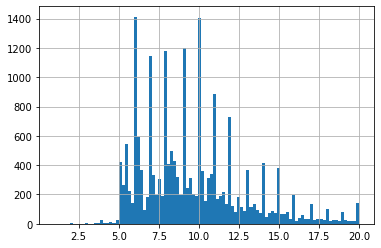

In [94]:
# выведим гистограмму от 1 до 20
data['kitchen_area'].hist(range =(1,20),bins=100)

Видим скопление от 5 до 15

### Изучим параметр цена объекта

In [95]:
# выведим сводную статистику по last_price
data['last_price'].describe()

count    2.369900e+04
mean     6.541549e+06
std      1.088701e+07
min      1.219000e+04
25%      3.400000e+06
50%      4.650000e+06
75%      6.800000e+06
max      7.630000e+08
Name: last_price, dtype: float64

In [96]:
# выведим с last_price max
data['last_price'].max()

763000000.0

In [97]:
# выведим с last_price min
data['last_price'].min()

12190.0

<AxesSubplot:>

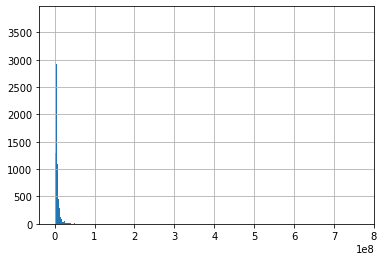

In [98]:
# выведим гистограмму от last_price_min до last_price_max 
data['last_price'].hist(range =(12190, 763000000),bins=1000)

<AxesSubplot:>

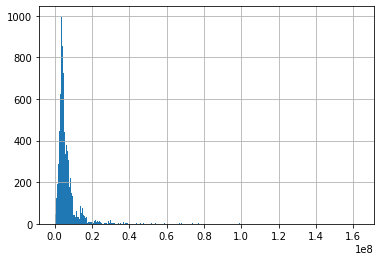

In [99]:
# выведим гистограмму от last_price_min до 163000000
data['last_price'].hist(range =(12190, 163000000),bins=1000)

<AxesSubplot:>

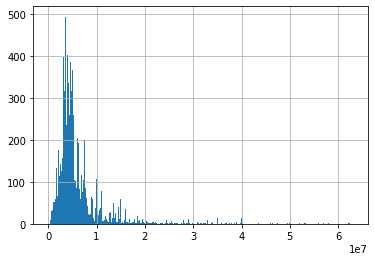

In [100]:
# выведим гистограмму от last_price_min до 63000000
data['last_price'].hist(range =(12190, 63000000),bins=1000)

<AxesSubplot:>

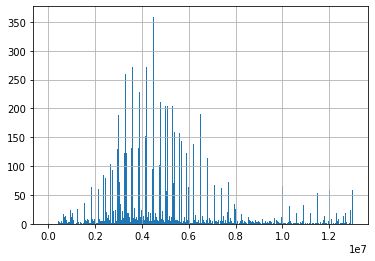

In [101]:
# выведим гистограмму от last_price_min до 13000000
data['last_price'].hist(range =(12190, 13000000),bins=1000)

На гистограмме видем что диапазон цен больше всего в промежутке от 2 млн до 7 млн

### Изучим параметр количество комнат

In [102]:
# выведим сводную статистику по rooms
data['rooms'].describe()

count    23699.000000
mean         2.070636
std          1.078405
min          0.000000
25%          1.000000
50%          2.000000
75%          3.000000
max         19.000000
Name: rooms, dtype: float64

<AxesSubplot:>

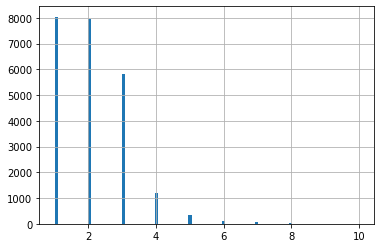

In [103]:
# выведим гистограмму от 1 до 10
data['rooms'].hist(range =(1, 10),bins=100)

Больше всего комнат от 1 до 3

### Изучим данные высота потолков

In [104]:
# выведим сводную статистику по ceiling_height
data['ceiling_height'].describe()

count    14504.000000
mean         2.771499
std          1.261056
min          1.000000
25%          2.520000
50%          2.650000
75%          2.800000
max        100.000000
Name: ceiling_height, dtype: float64

<AxesSubplot:>

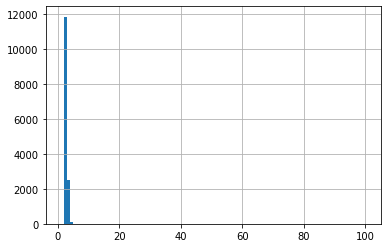

In [105]:
# выведим гистограмму от 1 до 100
data['ceiling_height'].hist(range =(1, 100),bins=100)

<AxesSubplot:>

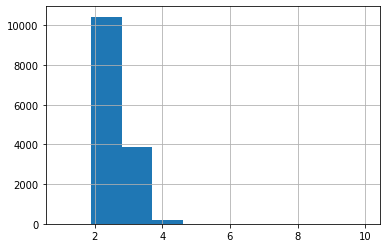

In [106]:
# выведим гистограмму от 1 до 10
data['ceiling_height'].hist(range =(1, 10),bins=10)

<AxesSubplot:>

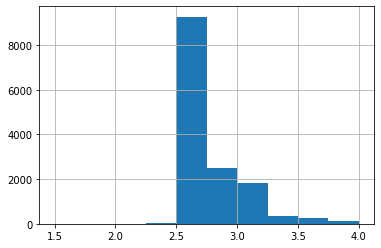

In [107]:
# выведим гистограмму от 1,5 до 4
data['ceiling_height'].hist(range =(1.5, 4),bins=10)

Больше всего квартир с высотой потолков от 2,5 м

### Изучим данные тип этажа квартиры («первый», «последний», «другой»)

In [108]:
# выведим сводную статистику по floor_type
data['floor_type'].describe()

count      23699
unique         3
top       другое
freq       17446
Name: floor_type, dtype: object

<AxesSubplot:>

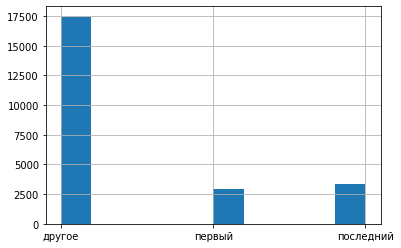

In [109]:
# выведим гистограмму
data['floor_type'].hist(bins=10)

Больше всего недвижимости с этажами другое.

### Изучим данные общее количество этажей в доме

In [110]:
# выведим сводную статистику по floors_total
data['floors_total'].describe()

count    23613.000000
mean        10.673824
std          6.597173
min          1.000000
25%          5.000000
50%          9.000000
75%         16.000000
max         60.000000
Name: floors_total, dtype: float64

<AxesSubplot:>

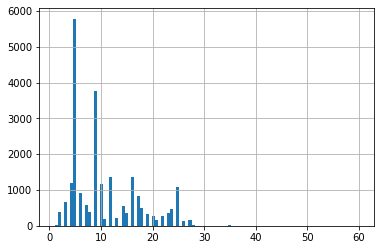

In [111]:
# выведим гистограмму
data['floors_total'].hist(bins=100)

<AxesSubplot:>

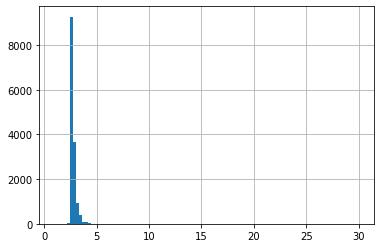

In [112]:
# выведим гистограмму от 1 этажа до 30 этажа
data['ceiling_height'].hist(range =(1, 30),bins=100)

<AxesSubplot:>

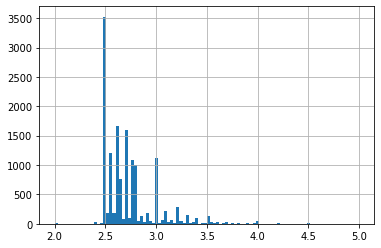

In [113]:
# выведим гистограмму от 2 этажа до 5 этажа
data['ceiling_height'].hist(range =(2, 5),bins=100)

Больше всего недвижимости от 2-х этажей до 3-х

### Изучим данные расстояние до центра города в метрах


In [114]:
# выведим сводную статистику по city_centers_nearest
data['city_centers_nearest'].describe()

count    18180.000000
mean     14191.277833
std       8608.386210
min        181.000000
25%       9238.000000
50%      13098.500000
75%      16293.000000
max      65968.000000
Name: city_centers_nearest, dtype: float64

<AxesSubplot:>

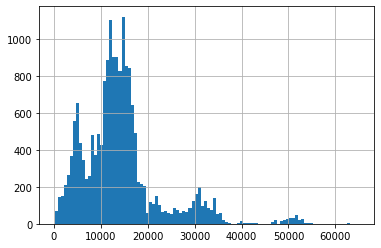

In [115]:
# вывыедим гисторгамму
data['city_centers_nearest'].hist(range =(181, 65000),bins=100)

<AxesSubplot:>

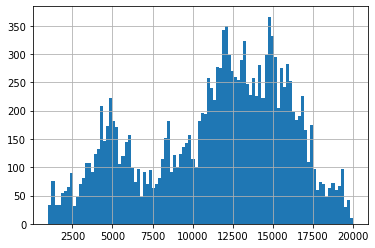

In [116]:
# вывыедим гисторгамму
data['city_centers_nearest'].hist(range =(1000, 20000),bins=100)

Больше всего недвижимости на растоянии от 10000 метров до 17500 метров


### Изучим данные расстояние до ближайшего парка

In [117]:
# выведим сводную статистику по parks_nearest
data['parks_nearest'].describe()

count    8079.000000
mean      490.804555
std       342.317995
min         1.000000
25%       288.000000
50%       455.000000
75%       612.000000
max      3190.000000
Name: parks_nearest, dtype: float64

<AxesSubplot:>

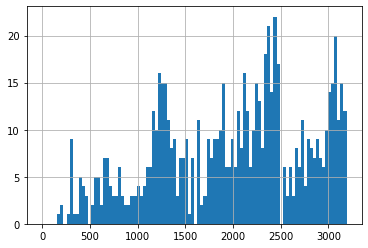

In [118]:
# вывыедим гисторгамму
data['city_centers_nearest'].hist(range =(1, 3190),bins=100)

<AxesSubplot:>

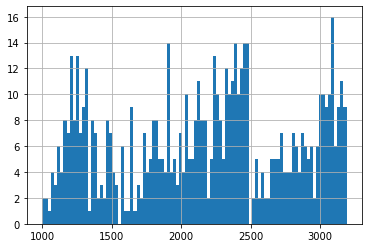

In [119]:
# вывыедим гисторгамму
data['city_centers_nearest'].hist(range =(1000, 3190),bins=100)

Отдоленность до парка равномерная, нет пика предложений.

### Вывод:


        - общая площадь недвижимости от 30 до 60 кв. больше всего
        - жилая площадь больше всего от 15 до 20 и от 27 до 35 м
        - площадь кухни больше всего от 5 до 15 м
        - цена объекта больше всего от 2 млн до 7 млн
        - количество комнат больше всего от 1 до 3-х комнат
        - высота потолков больше всегоо от 2 до 3 метров
        - тип этажа квартиры («первый», «последний», «другой») больше всего предложений «другой», а «первый» и «последний» практически на одном уровне
        - общее количество этажей в доме больше всего на 2 и 3 этажах
        - расстояние до центра города в метрах больше всего от 10000 метров = 10 км
        - расстояние до ближайшего парка равномерно нет максимального показатиля.

## Выполнено задание «Изучите, как быстро продавались квартиры (столбец `days_exposition`)»:

In [120]:
# Построим describe
data['days_exposition'].describe()

count    20518.000000
mean       180.888634
std        219.727988
min          1.000000
25%         45.000000
50%         95.000000
75%        232.000000
max       1580.000000
Name: days_exposition, dtype: float64

<AxesSubplot:>

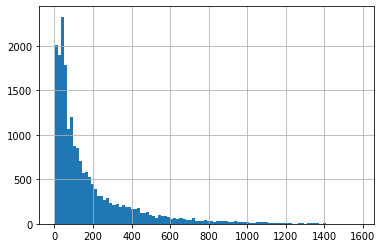

In [121]:
# вывыедим гисторгамму от 1 до 1580
data['days_exposition'].hist(range =(1, 1580),bins=100)

<AxesSubplot:>

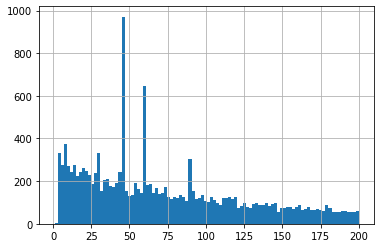

In [122]:
# вывыедим гисторгамму от 1 до 200
data['days_exposition'].hist(range =(1, 200),bins=100)

- Среднее значение = 180, квартиры продаются примерно в этом диапазоне периода.
- Медианное значение 95
- Быстрые продажи видим всплеск около 50 дней
- Необычно должгие продажи после 200 дней, больше среднего значения
- Выбиваются значения, возможно связанно с сезонностью продаж недвижимости, возможно не корректные данные

In [123]:
data_days_exposition = data[data['days_exposition'] >45]

In [124]:
data_days_exposition = data[data['days_exposition'] <50]

In [125]:
data_days_exposition.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 6289 entries, 11 to 23695
Data columns (total 33 columns):
 #   Column                           Non-Null Count  Dtype         
---  ------                           --------------  -----         
 0   total_images                     6289 non-null   int64         
 1   last_price                       6289 non-null   float64       
 2   total_area                       6289 non-null   float64       
 3   first_day_exposition             6289 non-null   datetime64[ns]
 4   rooms                            6289 non-null   int64         
 5   ceiling_height                   3513 non-null   float64       
 6   floors_total                     6269 non-null   float64       
 7   living_area                      5564 non-null   float64       
 8   floor                            6289 non-null   int64         
 9   is_apartment                     6289 non-null   object        
 10  studio                           6289 non-null   bool     

## Выполнено задание «Определите факторы, которые больше всего влияют на общую (полную) стоимость объекта». Построены графики, которые показывают зависимость цены от параметров:

Нужно посчитать кориляцию, статистическая взаимосвязь двух или более величин
- -1 указывает на совершенно отрицательную линейную корреляцию между двумя переменные
- 0 указывает на отсутствие линейной корреляции между двумя переменными
- 1 указывает на совершенно положительную линейную корреляцию между двумя переменными


    - общая площадь;
    - жилая площадь;
    - площадь кухни;
    - количество комнат;
    - тип этажа, на котором расположена квартира (первый, последний, другой);
    - дата размещения (день недели, месяц, год).

In [126]:
# Построим сводную 
display(data.pivot_table(index='floor', values=['last_price','total_area','living_area','kitchen_area','rooms']).corr())

,kitchen_area,last_price,living_area,rooms,total_area
kitchen_area,1.000000,0.361686,0.106517,0.094420,0.411305
last_price,0.361686,1.000000,0.655849,0.442449,0.738972
living_area,0.106517,0.655849,1.000000,0.897739,0.923741
rooms,0.094420,0.442449,0.897739,1.000000,0.811538
total_area,0.411305,0.738972,0.923741,0.811538,1.000000


Больше всего нулевых значений, значит отсутствует корреляция между двух переменных

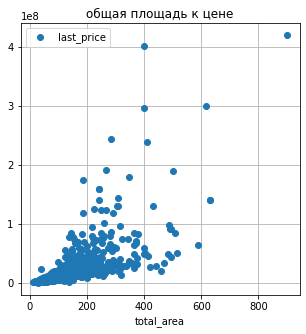

In [127]:
# Построим зависимость общая площадь к цене

(
    data.pivot_table(index='total_area', values='last_price')
    .plot(grid=True, style='o', figsize=(5, 5))
)
plt.title('общая площадь к цене')
plt.show()

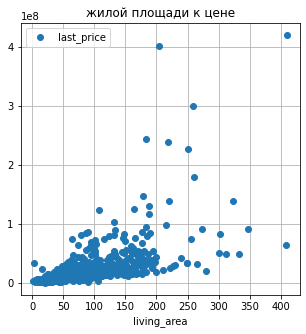

In [128]:
# построим зависмость жилой площади к цене

(
    data.pivot_table(index='living_area', values='last_price')
    .plot(grid=True, style='o', figsize=(5, 5))
)
plt.title('жилой площади к цене')
plt.show()

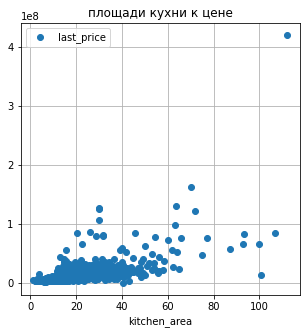

In [129]:
# Построим зависимость от площади кухни к цене

(
    data.pivot_table(index='kitchen_area', values='last_price')
    .plot(grid=True, style='o', figsize=(5, 5))
)
plt.title('площади кухни к цене')
plt.show()

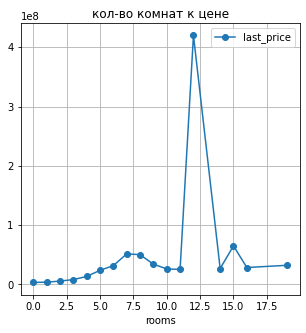

In [130]:
# Построим зависимость от кол-во комнат к цене

(
    data.pivot_table(index='rooms', values='last_price')
    .plot(grid=True, style='o-', figsize=(5, 5))
)
plt.title('кол-во комнат к цене')
plt.show()

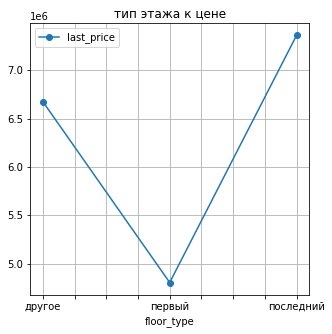

In [131]:
# построим зависимость тип этажа к цене

(
    data.pivot_table(index='floor_type', values='last_price')
    .plot(grid=True, style='o-', figsize=(5, 5))
)
plt.title('тип этажа к цене')
plt.show()

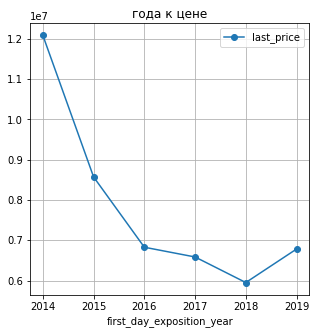

In [132]:
# построим зависимость года к цене

(
    data.pivot_table(index='first_day_exposition_year', values='last_price')
    .plot(grid=True, style='o-', figsize=(5, 5))
)
plt.title('года к цене')
plt.show()

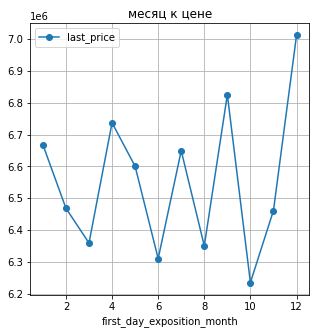

In [133]:
# построим зависимость месяц к цене

(
    data.pivot_table(index='first_day_exposition_month', values='last_price')
    .plot(grid=True, style='o-', figsize=(5, 5))
)
plt.title('месяц к цене')
plt.show()

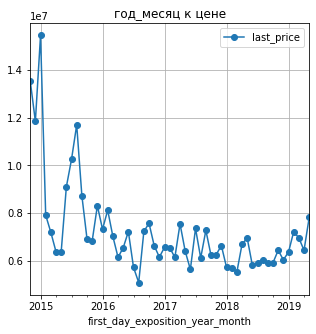

In [134]:
# построим зависимость год_месяц к цене

(
    data.pivot_table(index='first_day_exposition_year_month', values='last_price')
    .plot(grid=True, style='o-', figsize=(5, 5))
)
plt.title('год_месяц к цене')
plt.show()

Вывод по граыикам:

## Выполнено задание «Посчитайте среднюю цену одного квадратного метра в 10 населённых пунктах с наибольшим числом объявлений»:

In [135]:
# создадим сводную
settlements = data.pivot_table(index='locality_name', values=['last_price','total_area'] ,aggfunc=['sum','count'])

In [136]:
#выведим на экран
display(settlements)

sum                 count           
                  last_price total_area last_price total_area
locality_name                                                
69-й километр      1350000.0      52.70          1          1
unknown          330513201.0    3420.19         49         49
агалатово         14270000.0     196.70          4          4
александровская   17450000.0     237.00          2          2
алексеевка         1000000.0      45.00          1          1
...                      ...        ...        ...        ...
щеглово           61669000.0    1192.77         24         24
юкки              21750000.0     274.20          5          5
ялгино              777000.0      44.00          1          1
яльгелево         15450000.0     279.90          6          6
ям-тесово          1250000.0      89.50          2          2

[315 rows x 4 columns]

In [137]:
# переименнуем столбцы
settlements.columns=['last_price_sum','total_area_sum','last_price_count','total_area_count']

In [138]:
#выведим на экран
display(settlements)

,last_price_sum,total_area_sum,last_price_count,total_area_count
locality_name,,,,
69-й километр,1350000.0,52.70,1,1
unknown,330513201.0,3420.19,49,49
агалатово,14270000.0,196.70,4,4
александровская,17450000.0,237.00,2,2
алексеевка,1000000.0,45.00,1,1
...,...,...,...,...
щеглово,61669000.0,1192.77,24,24
юкки,21750000.0,274.20,5,5
ялгино,777000.0,44.00,1,1


In [139]:
# добавим столбец и расчитаем среднию стоимость 1 квадратного метра округленный до 2 значений после запятой

settlements['city_one_square_meter'] = (settlements['last_price_sum']/settlements['total_area_sum']).round(2)

In [140]:
#выведим на экран
display(settlements.head(10))

,last_price_sum,total_area_sum,last_price_count,total_area_count,city_one_square_meter
locality_name,,,,,
69-й километр,1350000.0,52.70,1,1,25616.70
unknown,330513201.0,3420.19,49,49,96635.92
агалатово,14270000.0,196.70,4,4,72547.03
александровская,17450000.0,237.00,2,2,73628.69
алексеевка,1000000.0,45.00,1,1,22222.22
аннино,49857830.0,786.00,16,16,63432.35
аро,9720000.0,190.30,3,3,51077.25
барышево,4000000.0,125.20,2,2,31948.88
батово,13970000.0,470.40,9,9,29698.13


In [141]:
# отсортируем по 'city_one_square_meter' и 'last_price_count' по убыванию
settlements.sort_values(by=(['city_one_square_meter'] and ['last_price_count']),ascending=False, inplace=True)

In [142]:
#выведим на экран 10 самых дорогих города с квадратным метром
display(settlements.head(10))

,last_price_sum,total_area_sum,last_price_count,total_area_count,city_one_square_meter
locality_name,,,,,
санкт-петербург,1.267507e+11,1017958.15,15721,15721,124514.62
мурино,2.170293e+09,26018.37,590,590,83413.86
кудрово,2.057301e+09,21898.63,472,472,93946.55
шушары,1.807556e+09,23681.36,440,440,76328.22
всеволожск,1.508049e+09,22296.83,398,398,67635.13
пушкин,2.387074e+09,22712.98,369,369,105097.36
колпино,1.339839e+09,17992.24,338,338,74467.62
парголово,1.467600e+09,16847.50,327,327,87110.87
гатчина,1.070919e+09,15639.48,307,307,68475.38


In [143]:
# отсортируем по 'city_one_square_meter и 'last_price_count' по возрастанию
settlements.sort_values(by=(['city_one_square_meter'] and ['last_price_count']),ascending=True, inplace=True)

In [144]:
#выведим на экран 10 самых дешевых города с квадратным метром
display(settlements.head(10))

,last_price_sum,total_area_sum,last_price_count,total_area_count,city_one_square_meter
locality_name,,,,,
69-й километр,1350000.0,52.7,1,1,25616.70
почап,850000.0,53.0,1,1,16037.74
ялгино,777000.0,44.0,1,1,17659.09
алексеевка,1000000.0,45.0,1,1,22222.22
плоское,1100000.0,52.6,1,1,20912.55
белоостров,2400000.0,36.0,1,1,66666.67
шум,2000000.0,59.0,1,1,33898.31
шугозеро,950000.0,57.2,1,1,16608.39
пикколово,3850000.0,72.3,1,1,53250.35


## Выполнено задание «Выделите квартиры в Санкт-Петербурге с помощью столбца locality_name и вычислите их среднюю стоимость на разном удалении от центра»

In [145]:
# создадим сводную
distance_settlement = data.pivot_table(index=['locality_name','dist_city_center_category'], values=['last_price','total_area','dist_to_the_city_center'] ,aggfunc=['sum','count'])


In [146]:
distance_settlement.head(10)

sum               \
                                        dist_to_the_city_center   last_price   
locality_name dist_city_center_category                                        
69-й километр A_city_center                                 0.0          0.0   
              B_city_center                                 0.0          0.0   
              C_city_center                                 0.0          0.0   
              D_city_center                                 0.0          0.0   
              E_city_center                                 0.0          0.0   
unknown       A_city_center                                77.0  162250000.0   
              B_city_center                               100.0   67280000.0   
              C_city_center                                 0.0          0.0   
              D_city_center                               153.0   36952753.0   
              E_city_center                               129.0   28972148.0   

                                                                     count  \
                                        total_area dist_to_the_city_center   
locality_name dist_city_center_category                                      
69-й километр A_city_center                   0.00                       0   
              B_city_center                   0.00                       0   
              C_city_center                   0.00                       0   
              D_city_center                   0.00                       0   
              E_city_center                   0.00                       0   
unknown       A_city_center                1441.29                      18   
              B_city_center                 604.70                      10   
              C_city_center                   0.00                       0   
              D_city_center                 437.80                       9   
              E_city_center                 395.60                       4   

                                                               
                                        last_price total_area  
locality_name dist_city_center_category                        
69-й километр A_city_center                      0          0  
              B_city_center                      0          0  
              C_city_center                      0          0  
              D_city_center                      0          0  
              E_city_center                      0          0  
unknown       A_city_center                     18         18  
              B_city_center                     10         10  
              C_city_center                      0          0  
              D_city_center                      9          9  
              E_city_center                      4          4

Супер пупер сводная, но ничего не понятно, надо повертеть и добавить среднию стоимость по удаленности

In [147]:
# создадим таблицу где будет только Санкт-Петербург
city_spb = data[data['locality_name'] == 'санкт-петербург']

In [148]:
# выведим на экран 
city_spb.head(10)

,total_images,last_price,total_area,first_day_exposition,rooms,ceiling_height,floors_total,living_area,floor,is_apartment,...,first_day_exposition_year_month,first_day_exposition_month,first_day_exposition_year,last_price_category,price_per_square_meter,price_per_square_meter_category,floor_type,dist_to_the_city_center,dist_city_center_category,total_area_category
0,20,13000000.0,108.0,2019-03-07,3,2.70,16.0,51.0,8,False,...,2019-03,3,2019,E_price,120370.0,E_price_square_meter,другое,16.0,D_city_center,10
2,10,5196000.0,56.0,2015-08-20,2,NaN,5.0,34.3,4,False,...,2015-08,8,2015,C_price,92786.0,C_price_square_meter,другое,14.0,C_city_center,6
3,0,64900000.0,159.0,2015-07-24,3,NaN,14.0,NaN,9,False,...,2015-07,7,2015,E_price,408176.0,E_price_square_meter,другое,7.0,A_city_center,10
4,2,10000000.0,100.0,2018-06-19,2,3.03,14.0,32.0,13,False,...,2018-06,6,2018,E_price,100000.0,C_price_square_meter,другое,8.0,A_city_center,10
7,5,7915000.0,71.6,2019-04-18,2,NaN,24.0,NaN,22,False,...,2019-04,4,2019,E_price,110545.0,D_price_square_meter,другое,12.0,B_city_center,8
9,18,5400000.0,61.0,2017-02-26,3,2.50,9.0,43.6,7,False,...,2017-02,2,2017,D_price,88525.0,C_price_square_meter,другое,15.0,D_city_center,7
10,5,5050000.0,39.6,2017-11-16,1,2.67,12.0,20.3,3,False,...,2017-11,11,2017,C_price,127525.0,E_price_square_meter,другое,14.0,C_city_center,3
15,16,4650000.0,39.0,2017-11-18,1,NaN,14.0,20.5,5,False,...,2017-11,11,2017,C_price,119231.0,D_price_square_meter,другое,14.0,C_city_center,3
16,11,6700000.0,82.0,2017-11-23,3,3.05,5.0,55.6,1,False,...,2017-11,11,2017,D_price,81707.0,B_price_square_meter,первый,11.0,B_city_center,9
17,6,4180000.0,36.0,2016-09-09,1,NaN,17.0,16.5,7,False,...,2016-09,9,2016,C_price,116111.0,D_price_square_meter,другое,15.0,D_city_center,2


In [149]:
# создадим сводную
distance_settlement_spb = data.pivot_table(index=['dist_city_center_category'], values=['last_price'] ,aggfunc=['sum','count'])

In [150]:
# выведим на экран
display(distance_settlement_spb)

,sum,count
,last_price,last_price
dist_city_center_category,,
A_city_center,5.861375e+10,4140
B_city_center,2.558376e+10,4105
C_city_center,1.606276e+10,2736
D_city_center,2.085295e+10,3752
E_city_center,1.656366e+10,3447


- Расшифровка категорийности растояния до центра:
 - A_city_center  [0.18, 7.756]
 - B_city_center  [7.756, 11.909]
 - C_city_center  [11.909, 14.45]
 - D_city_center [14.45, 17.256]
 - E_city_center [17.256, 65.968]


In [151]:
# переименнуем столбцы
distance_settlement_spb.columns=['last_price_sum','last_price_count']

In [152]:
# выведим на экран
display(distance_settlement_spb)

,last_price_sum,last_price_count
dist_city_center_category,,
A_city_center,5.861375e+10,4140
B_city_center,2.558376e+10,4105
C_city_center,1.606276e+10,2736
D_city_center,2.085295e+10,3752
E_city_center,1.656366e+10,3447


In [153]:
# добавим столбец среднюю стоимость недвижимости

distance_settlement_spb['city_last_price_agg'] = (distance_settlement_spb['last_price_sum']/distance_settlement_spb['last_price_count']).round(2)

In [154]:
# выведим на экран
display(distance_settlement_spb)

,last_price_sum,last_price_count,city_last_price_agg
dist_city_center_category,,,
A_city_center,5.861375e+10,4140,14157910.20
B_city_center,2.558376e+10,4105,6232340.21
C_city_center,1.606276e+10,2736,5870890.62
D_city_center,2.085295e+10,3752,5557821.57
E_city_center,1.656366e+10,3447,4805238.61


Вывод, чем ближе недвижимость к центру тем дороже средняя цена

In [156]:
# создадим сводную
distance_settlement_spb_km = data.pivot_table(index=['dist_to_the_city_center'], values=['last_price'] ,aggfunc=['sum','count'])

In [157]:
# выведим на экран
display(distance_settlement_spb_km.head(10))

,sum,count
,last_price,last_price
dist_to_the_city_center,,
0.0,8.491261e+08,27
1.0,4.083630e+09,193
2.0,5.538379e+09,311
3.0,3.908153e+09,352
4.0,9.236344e+09,696
5.0,1.336179e+10,924
6.0,9.479143e+09,618
7.0,6.205564e+09,420


In [158]:
# переименнуем столбцы
distance_settlement_spb_km.columns=['last_price_sum','last_price_count']

In [160]:
# выведим на экран
display(distance_settlement_spb_km)

,last_price_sum,last_price_count
dist_to_the_city_center,,
0.0,8.491261e+08,27
1.0,4.083630e+09,193
2.0,5.538379e+09,311
3.0,3.908153e+09,352
4.0,9.236344e+09,696
...,...,...
61.0,3.200000e+06,1
62.0,3.200000e+06,1
63.0,3.600000e+06,1


In [161]:
distance_settlement_spb_km['city_last_price_agg'] = (distance_settlement_spb_km['last_price_sum']/distance_settlement_spb_km['last_price_count']).round(2)

In [164]:
# выведим на экран
display(distance_settlement_spb_km.head(10))

,last_price_sum,last_price_count,city_last_price_agg
dist_to_the_city_center,,,
0.0,8.491261e+08,27,31449115.85
1.0,4.083630e+09,193,21158706.73
2.0,5.538379e+09,311,17808292.86
3.0,3.908153e+09,352,11102708.38
4.0,9.236344e+09,696,13270609.65
5.0,1.336179e+10,924,14460813.18
6.0,9.479143e+09,618,15338418.39
7.0,6.205564e+09,420,14775152.59
8.0,5.951617e+09,599,9935921.44


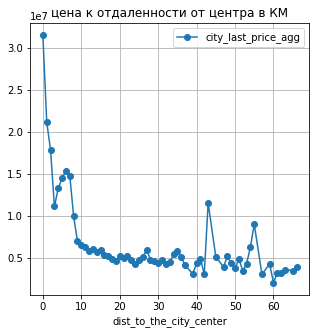

In [166]:
# построим график зависимость средней цены от отдаленности от центра в КМ

(
    distance_settlement_spb_km.pivot_table(index='dist_to_the_city_center', values='city_last_price_agg')
    .plot(grid=True, style='o-', figsize=(5, 5))
)
plt.title('цена к отдаленности от центра в КМ')
plt.show()

Вывод: 
- самые дорогая недвижимост о 0 до 10 км от центра
- виден всплеск от 40 км, скорее всего это дорогие загородные дома.

## Напишите общий вывод

Что нужно было сделать - Вам нужно научиться определять рыночную стоимость объектов недвижимости

Как быстро продаются квартиры?
 - Медианно квартиры продаются до 180 дней
 - Быстрые продажи до 50 дней
 - Должгие продажи после 200 дней

Какие факторы, которые больше всего влияют на общую (полную) стоимость объекта?
 - растояние до центра города
 - площадь недвижимости
 - этаж недвижимости
 - цена за 1 квадратный метр

Какая средняя цена за квадратный метр в 10 населённых пунктах с наибольшим числом объявлений?
				
- санкт-петербург	124514.62
- мурино	83413.86
- кудрово	93946.55
- шушары	76328.22
- всеволожск 67635.13
- пушкин 	105097.36
- колпино 74467.62
- парголово 87110.87
- гатчина	68475.38
- выборг 57898.14


Какая в Санкт-Петербурге среднняя стоимостью на разном удалении от центра?


 - A_city_center  [0.18, 7.756] км - 14687559.21
 - B_city_center  [7.756, 11.909] км - 6857308.75
 - C_city_center  [11.909, 14.45] км - 5901756.51
 - D_city_center [14.45, 17.256] км - 5615648.01
 - E_city_center [17.256, 65.968] км - 4797494.64

Заключение: 
- Самая дорогая недвижимость находится в Санкт-петербурге с отдоленность к центру от 0 до 10 км,
- Самые популярные квартиры с количеством комнат от 1 до 3-х, общей площадью от 30 до 60 кв. метров , не первым этажем с высотой потолков от 2,5 метров. 
- Медианно самая быстрая сделка может пройти на 95 дней.

### Привет ревьюер, не суди строго, старалась , очень сложный проект для меня 

<div class="alert alert-block alert-info">

## Итоговый комментарии от ревьюера:
    
#### Успех

Спасибо большое тебе за такую качественную работу. Мне было приятно проверять проект и делиться обратной связью. Особенно впечатлила Предобработка данных. Все достаточно структурировано и последовательно. Ты применяешь верные навыки для работы с кодом. Еще хочу отметить понятные и информативные графики. Однако, в проекте есть несколько замечаний, которые надо исправить:

* Промежуточные выводы добавить.
* Посчитать сколько уникальных значений осталось после устранения неявных дублей.
* Найти и пояснить выбивающиеся значения на графике по дням в публикации.
* Подправить некотрые графики.
* Переделать вопрос по изучению зависимости от центра СБП. 
       
Еще я оставил рекомендации. Очень надеюсь, что ты учтешь их в этом и последующих проектах.
       
Жду проект после доработки. Уверен, ты справишься.
</div>

**Чек-лист готовности проекта**

Поставьте 'x' в выполненных пунктах. Далее нажмите Shift+Enter.

- [x]  Файл с данными открыт.
- [x]  Файл с данными изучен: выведены первые строки, использован метод `info()`, построены гистограммы.
- [x]  Найдены пропущенные значения.
- [x]  Пропущенные значения заполнены там, где это возможно.
- [x]  Объяснено, какие пропущенные значения обнаружены.
- [x]  В каждом столбце установлен корректный тип данных.
- [x]  Объяснено, в каких столбцах изменён тип данных и почему.
- [x]  Устранены неявные дубликаты в названиях населённых пунктов.
- [x]  Обработаны редкие и выбивающиеся значения (аномалии).
- [x]  В таблицу добавлены новые параметры:
       – цена одного квадратного метра;
       – день публикации объявления (0 - понедельник, 1 - вторник и т. д.);
       – месяц публикации объявления;
       – год публикации объявления;
       – тип этажа квартиры (значения — «первый», «последний», «другой»);
       – расстояние до центра города в километрах.
- [x]  Изучены и описаны параметры:
        - общая площадь;
        - жилая площадь;
        - площадь кухни;
        - цена объекта;
        - количество комнат;
        - высота потолков;
        - тип этажа квартиры («первый», «последний», «другой»);
        - общее количество этажей в доме;
        - расстояние до центра города в метрах;
        - расстояние до ближайшего парка.
- [x]  Выполнено задание «Изучите, как быстро продавались квартиры (столбец `days_exposition`)»:
    - построена гистограмма;
    - рассчитаны среднее и медиана;
    - описано, сколько обычно занимает продажа и указано, какие продажи можно считать быстрыми, а какие — необычно долгими.
- [x]  Выполнено задание «Определите факторы, которые больше всего влияют на общую (полную) стоимость объекта». Построены графики, которые показывают зависимость цены от параметров:
        - общая площадь;
        - жилая площадь;
        - площадь кухни;
        - количество комнат;
        - тип этажа, на котором расположена квартира (первый, последний, другой);
        - дата размещения (день недели, месяц, год).
- [x]  Выполнено задание «Посчитайте среднюю цену одного квадратного метра в 10 населённых пунктах с наибольшим числом объявлений»:
    - выделены населённые пункты с самой высокой и низкой стоимостью квадратного метра.
- [x]  Выполнено задание «Выделите квартиры в Санкт-Петербурге с помощью столбца `locality_name` и вычислите их среднюю стоимость на разном удалении от центра»:
    -  учтён каждый километр расстояния, известны средние цены квартир в одном километре от центра, в двух и так далее;
    -  описано, как стоимость объекта зависит от расстояния до центра города;
    -  построен график изменения средней цены для каждого километра от центра Петербурга.
- [x]  На каждом этапе сделаны промежуточные выводы.
- [x]  В конце проекта сделан общий вывод.